In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import albumentations as A
from sklearn.ensemble import RandomForestClassifier

In [ ]:
base_path = "/content/drive/Shareddrives/PROJECT PCD"
train_base = os.path.join(
    base_path,
    "/content/drive/Shareddrives/PROJECT PCD/training_data"
)
validation_path = os.path.join(
    base_path,
    "/content/drive/Shareddrives/PROJECT PCD/validation_data",
    "/content/drive/Shareddrives/PROJECT PCD/validation_data/C-NMC_test_prelim_phase_data"
)
validation_csv_path = os.path.join(
    base_path,
    "/content/drive/Shareddrives/PROJECT PCD/validation_data",
    "/content/drive/Shareddrives/PROJECT PCD/validation_data/C-NMC_test_prelim_phase_data_labels.csv"
)

## Analysis Data Eksploratif

In [ ]:
folds = os.listdir(train_base)

print("Fold yang tersedia:")
print(folds)

Fold yang tersedia:
['fold_2', 'fold_1', 'fold_0']


In [ ]:
data_info = []
for fold in folds:
    fold_path = os.path.join(train_base, fold)
    classes = os.listdir(fold_path)
    for cls in classes:
        class_path = os.path.join(fold_path, cls)
        total_images = len(os.listdir(class_path))
        data_info.append([fold, cls, total_images])

In [ ]:
df = pd.DataFrame(data_info, columns=["Fold", "Class", "Total"])
print(df)

     Fold Class  Total
0  fold_2   hem   1096
1  fold_2   all   2487
2  fold_1   hem   1163
3  fold_1   all   2418
4  fold_0   hem   1130
5  fold_0   all   2397


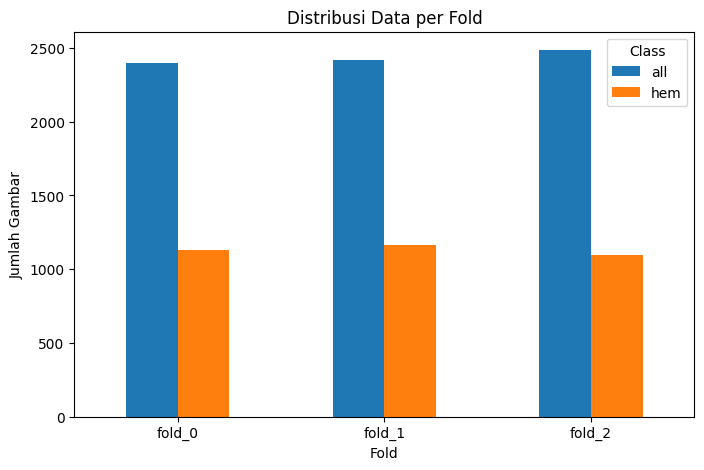

In [ ]:
pivot_df = df.pivot(index="Fold", columns="Class", values="Total")
pivot_df.plot(kind="bar", figsize=(8,5))
plt.title("Distribusi Data per Fold")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=0)
plt.show()

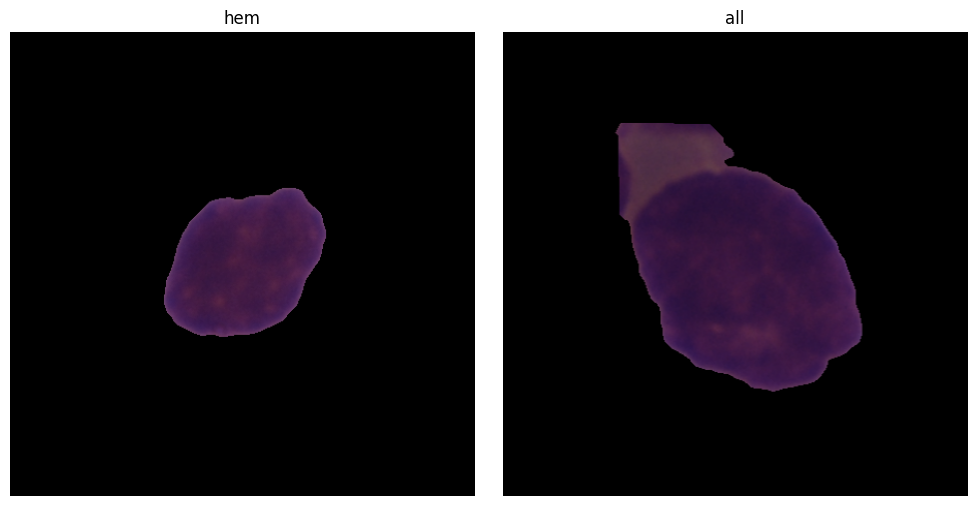

In [ ]:
plt.figure(figsize=(10,5))
sample_fold = folds[0]
sample_fold_path = os.path.join(train_base, sample_fold)
classes = os.listdir(sample_fold_path)
for i, cls in enumerate(classes):
    class_path = os.path.join(sample_fold_path, cls)
    sample_image = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, sample_image)
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img_rgb)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
sizes = []

for fold in folds:
    fold_path = os.path.join(train_base, fold)
    classes = os.listdir(fold_path)
    for cls in classes:
        class_path = os.path.join(fold_path, cls)
        files = os.listdir(class_path)[:20]
        for file in files:
            path = os.path.join(class_path, file)
            img = cv2.imread(path)
            if img is not None:
                h, w, c = img.shape
                sizes.append((w, h))

sizes_df = pd.DataFrame(sizes, columns=["Width", "Height"])
print("\nStatistik ukuran gambar:")
print(sizes_df.describe())


Statistik ukuran gambar:
       Width  Height
count  120.0   120.0
mean   450.0   450.0
std      0.0     0.0
min    450.0   450.0
25%    450.0   450.0
50%    450.0   450.0
75%    450.0   450.0
max    450.0   450.0


## Preprocessing

In [ ]:
train_aug = A.Compose([
    A.Rotate(limit=20, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=20,
        p=0.7
    )
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
classes = {
    "all": 1,
    "hem": 0
}

In [ ]:
def load_dataset(dataset_path):

    image_paths = []
    labels = []

    for cls in classes:

        class_path = os.path.join(
            dataset_path,
            cls
        )

        if not os.path.exists(class_path):
            continue

        for file in os.listdir(class_path):

            img_path = os.path.join(
                class_path,
                file
            )

            image_paths.append(img_path)

            labels.append(classes[cls])

    return image_paths, labels

### Grayscale

In [ ]:
def grayscale_image(img):

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    return gray

### Billateral Filtering

In [ ]:
def bilateral_image(gray):

    bilateral = cv2.bilateralFilter(
        gray,
        9,
        75,
        75
    )

    return bilateral

### Feature Extraction (GLCM)

In [ ]:
def extract_glcm_features(image):

    glcm = graycomatrix(
        image,
        distances=[1],
        angles=[
            0,
            np.pi/4,
            np.pi/2,
            3*np.pi/4
        ],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(
        glcm,
        'contrast'
    ).mean()

    correlation = graycoprops(
        glcm,
        'correlation'
    ).mean()

    energy = graycoprops(
        glcm,
        'energy'
    ).mean()

    homogeneity = graycoprops(
        glcm,
        'homogeneity'
    ).mean()

    dissimilarity = graycoprops(
        glcm,
        'dissimilarity'
    ).mean()

    asm = graycoprops(
        glcm,
        'ASM'
    ).mean()

    return [
        contrast,
        correlation,
        energy,
        homogeneity,
        dissimilarity,
        asm
    ]

In [ ]:
def load_all_training(use_bilateral=False):

    X_all = []
    y_all = []

    for fold in os.listdir(train_base):
        fold_path = os.path.join(
            train_base,
            fold
        )
        image_paths, labels = load_dataset(
            fold_path
        )

        for i in range(len(image_paths)):
            img = cv2.imread(
                image_paths[i]
            )

            if img is None:
                continue
            gray = grayscale_image(img)

            if use_bilateral:
                processed = bilateral_image(
                    gray
                )
            else:
                processed = gray
            feature = extract_glcm_features(
                processed
            )

            X_all.append(feature)
            y_all.append(labels[i])

            if labels[i] == 0:

                aug_img = train_aug(
                    image=img
                )["image"]

                gray_aug = grayscale_image(
                    aug_img
                )

                if use_bilateral:
                    processed_aug = bilateral_image(
                        gray_aug
                    )
                else:
                    processed_aug = gray_aug

                feature_aug = extract_glcm_features(
                    processed_aug
                )

                X_all.append(feature_aug)
                y_all.append(labels[i])

    return np.array(X_all), np.array(y_all)

In [ ]:
original_all = 0
original_hem = 0

for fold in folds:

    fold_path = os.path.join(
        train_base,
        fold
    )

    original_all += len(
        os.listdir(
            os.path.join(fold_path, "all")
        )
    )

    original_hem += len(
        os.listdir(
            os.path.join(fold_path, "hem")
        )
    )

print("Sebelum Augmentasi")
print("ALL :", original_all)
print("HEM :", original_hem)

print("\nSetelah Augmentasi")
print("ALL :", original_all)
print("HEM :", original_hem * 2)

Sebelum Augmentasi
ALL : 7302
HEM : 3389

Setelah Augmentasi
ALL : 7302
HEM : 6778


In [ ]:
def process_dataset_with_csv(image_folder, csv_path, use_bilateral=False):

    X = []
    y = []

    df = pd.read_csv("/content/drive/Shareddrives/PROJECT PCD/validation_data/C-NMC_test_prelim_phase_data_labels.csv")

    for i in range(len(df)):

        file_name = df.iloc[i]['new_names']
        label = df.iloc[i]['labels']

        img_path = os.path.join(
            image_folder,
            file_name
        )
        img = cv2.imread(img_path)

        if img is None:
            continue
        gray = grayscale_image(img)

        if use_bilateral:
            processed = bilateral_image(gray)
        else:
            processed = gray
        feature = extract_glcm_features(
            processed
        )

        X.append(feature)
        y.append(label)

    return np.array(X), np.array(y)

## GLCM > SVM dan Random Forest

In [ ]:
X_train_1, y_train_1 = load_all_training(
    use_bilateral=False
)

In [ ]:
X_val_1, y_val_1 = process_dataset_with_csv(
    validation_path,
    validation_csv_path,
    use_bilateral=False
)

In [ ]:
scaler = StandardScaler()

X_train_scaler1 = scaler.fit_transform(X_train_1)
X_val_scaler1 = scaler.transform(X_val_1)

### SVM

In [ ]:
svm_1 = SVC(
    kernel='rbf',
    class_weight='balanced'
)

In [ ]:
svm_1.fit(
    X_train_scaler1,
    y_train_1
)

SVC(class_weight='balanced')

Validation Prediction

In [ ]:
y_val_pred_1 = svm_1.predict(
    X_val_scaler1
)

Evaluasi SVM

In [ ]:
val_acc_1 = accuracy_score(
    y_val_1,
    y_val_pred_1
)

print(f"\nValidation Accuracy : {val_acc_1:.4f}")


Validation Accuracy : 0.7156


In [ ]:
print("\nClassification Report SVM Tanpa Bilateral Filtering:\n")

print(
    classification_report(
        y_val_1,
        y_val_pred_1,
        target_names=[
            "hem",
            "all"
        ]
    )
)


Classification Report SVM Tanpa Bilateral Filtering:

              precision    recall  f1-score   support

         hem       0.67      0.36      0.47       648
         all       0.73      0.90      0.81      1219

    accuracy                           0.72      1867
   macro avg       0.70      0.63      0.64      1867
weighted avg       0.71      0.72      0.69      1867



In [ ]:
cm_1 = confusion_matrix(
    y_val_1,
    y_val_pred_1
)

print("\nConfusion Matrix:\n")

print(cm_1)


Confusion Matrix:

[[ 235  413]
 [ 118 1101]]


### Random Forest

In [ ]:
rf_1 = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_1.fit(
    X_train_scaler1,
    y_train_1
)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

Validation Prediction

In [ ]:
y_pred_rf_1 = rf_1.predict(
    X_val_scaler1
)

Evaluasi Random Forest

In [ ]:
rf_acc_1 = accuracy_score(
    y_val_1,
    y_pred_rf_1
)

print(f"\nValidation Accuracy : {rf_acc_1:.4f}")


Validation Accuracy : 0.7113


In [ ]:
print("Classification Report Random Forest Tanpa Bilateral Filtering:\n")
print(
    classification_report(
        y_val_1,
        y_pred_rf_1,
        target_names=["hem","all"]
    )
)

Classification Report Random Forest Tanpa Bilateral Filtering:

              precision    recall  f1-score   support

         hem       0.64      0.38      0.48       648
         all       0.73      0.89      0.80      1219

    accuracy                           0.71      1867
   macro avg       0.69      0.63      0.64      1867
weighted avg       0.70      0.71      0.69      1867



In [ ]:
cm_rf_1 = confusion_matrix(
    y_val_1,
    y_pred_rf_1
)

print("\nConfusion Matrix:\n")

print(cm_rf_1)


Confusion Matrix:

[[ 246  402]
 [ 137 1082]]


## Bilateral > GLCM > SVM dan Random Forest

In [ ]:
X_train_2, y_train_2 = load_all_training(
    use_bilateral=True
)

In [ ]:
X_val_2, y_val_2 = process_dataset_with_csv(
    validation_path,
    validation_csv_path,
    use_bilateral=True
)

In [ ]:
scaler = StandardScaler()

X_train_scaler2 = scaler.fit_transform(X_train_2)
X_val_scaler2 = scaler.transform(X_val_2)

### SVM

In [ ]:
svm_2 = SVC(
    kernel='rbf',
    class_weight='balanced'
)

In [ ]:
svm_2.fit(
    X_train_scaler2,
    y_train_2
)

SVC(class_weight='balanced')

Validation Prediction

In [ ]:
y_val_pred_2 = svm_2.predict(
    X_val_scaler2
)

Evaluasi SVM

In [ ]:
val_acc_2 = accuracy_score(
    y_val_2,
    y_val_pred_2
)

print(f"\nValidation Accuracy : {val_acc_2:.4f}")


Validation Accuracy : 0.7038


In [ ]:
print("\nClassification Report SVM Dengan Bilateral Filtering:\n")

print(
    classification_report(
        y_val_2,
        y_val_pred_2,
        target_names=[
            "hem",
            "all"
        ]
    )
)


Classification Report SVM Dengan Bilateral Filtering:

              precision    recall  f1-score   support

         hem       0.62      0.37      0.47       648
         all       0.72      0.88      0.80      1219

    accuracy                           0.70      1867
   macro avg       0.67      0.63      0.63      1867
weighted avg       0.69      0.70      0.68      1867



In [ ]:
cm_2 = confusion_matrix(
    y_val_2,
    y_val_pred_2
)

print("\nConfusion Matrix:\n")

print(cm_2)


Confusion Matrix:

[[ 241  407]
 [ 146 1073]]


### Random Forest

In [ ]:
rf_2 = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_2.fit(
    X_train_scaler2,
    y_train_2
)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

Validation Prediction

In [ ]:
y_pred_rf_2 = rf_2.predict(
    X_val_scaler2
)

Evaluasi Random Forest

In [ ]:
rf_acc_2 = accuracy_score(
    y_val_2,
    y_pred_rf_2
)

print(f"\nValidation Accuracy : {rf_acc_2:.4f}")


Validation Accuracy : 0.6813


In [ ]:
print("Classification Report Random Forest Dengan Bilateral Filtering:\n")
print(
    classification_report(
        y_val_2,
        y_pred_rf_2,
        target_names=["hem","all"]
    )
)

Classification Report Random Forest Dengan Bilateral Filtering:

              precision    recall  f1-score   support

         hem       0.56      0.36      0.44       648
         all       0.72      0.85      0.78      1219

    accuracy                           0.68      1867
   macro avg       0.64      0.61      0.61      1867
weighted avg       0.66      0.68      0.66      1867



In [ ]:
cm_rf_2 = confusion_matrix(
    y_val_2,
    y_pred_rf_2
)

print("\nConfusion Matrix:\n")

print(cm_rf_2)


Confusion Matrix:

[[ 236  412]
 [ 183 1036]]
